In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import optuna

# Selected tickers
etf_tickers = ['AAPL', 'AMZN','MSFT', 'NFLX','QQQ','SPY','BTC-USD']

# Download data from 2018 onwards
start_date = '2018-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

# Download historical data
etf_data = {}
for ticker in etf_tickers:
    try:
        data = yf.download(ticker, start=start_date, end=end_date)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        etf_data[ticker] = data
        print(f"Downloaded {ticker}: {len(data)} rows")
    except Exception as e:
        print(f"Error downloading {ticker}: {e}")

print("Available Assets:", list(etf_data.keys()))

[*********************100%***********************]  1 of 1 completed


Downloaded AAPL: 2064 rows


[*********************100%***********************]  1 of 1 completed


Downloaded AMZN: 2064 rows


[*********************100%***********************]  1 of 1 completed


...

Downloaded QQQ: 2064 rows


[*********************100%***********************]  1 of 1 completed


Downloaded SPY: 2064 rows


[*********************100%***********************]  1 of 1 completed

Downloaded BTC-USD: 3001 rows
Available Assets: ['AAPL', 'AMZN', 'MSFT', 'NFLX', 'QQQ', 'SPY', 'BTC-USD']


In [3]:
import optuna
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

optuna.logging.set_verbosity(optuna.logging.WARNING)

def calculate_kama(series, n=10, fast=2, slow=30):
    change     = abs(series - series.shift(n))
    volatility = abs(series - series.shift(1)).rolling(window=n).sum()
    er  = change / (volatility + 1e-9)
    sc  = ((er * (2/(fast+1) - 2/(slow+1))) + 2/(slow+1))**2
    kama = np.zeros(len(series))
    kama[n] = series.iloc[n]
    for i in range(n + 1, len(series)):
        kama[i] = kama[i-1] + sc.iloc[i] * (series.iloc[i] - kama[i-1])
    out = pd.Series(kama, index=series.index)
    out.iloc[:n] = np.nan
    return out, er

def eval_params(params, data):
    close = data['Close']
    if isinstance(close, pd.DataFrame): close = close.iloc[:, 0]
    ks, _ = calculate_kama(close, n=params['n_short'], fast=params['fast_short'], slow=params['slow_short'])
    kl, _ = calculate_kama(close, n=params['n_long'],  fast=params['fast_long'],  slow=params['slow_long'])
    pos     = (ks > kl).astype(int).shift(1).fillna(0)
    returns = close.pct_change() * pos
    sharpe  = (returns.mean() / (returns.std() + 1e-9)) * np.sqrt(252) if returns.std() > 0 else 0
    vol     = returns.std() * np.sqrt(252)
    winrate = (returns[returns != 0] > 0).mean() if (returns != 0).any() else 0
    trades  = (pos.diff() != 0).sum()
    return sharpe, vol, winrate, trades

def objective(trial, data):
    close = data['Close']
    if isinstance(close, pd.DataFrame): close = close.iloc[:, 0]
    params = {
        'n_short':    trial.suggest_int('n_short',    5,  50),
        'fast_short': trial.suggest_int('fast_short', 2,   5),
        'slow_short': trial.suggest_int('slow_short', 20, 50),
        'n_long':     trial.suggest_int('n_long',     50, 200),
        'fast_long':  trial.suggest_int('fast_long',  2,   5),
        'slow_long':  trial.suggest_int('slow_long',  20, 50),
    }
    ks, _ = calculate_kama(close, n=params['n_short'], fast=params['fast_short'], slow=params['slow_short'])
    kl, _ = calculate_kama(close, n=params['n_long'],  fast=params['fast_long'],  slow=params['slow_long'])
    pos     = (ks > kl).astype(int).shift(1)
    returns = close.pct_change() * pos
    trades  = (pos.diff() != 0).sum()
    years   = len(close) / 252
    if trades / years <= 2:
        return -999
    if returns.std() == 0 or np.isnan(returns.std()):
        return 0
    return (returns.mean() / returns.std()) * np.sqrt(252)

studies = {}
for ticker in etf_tickers:
    print(f"\n--- Optimizing {ticker} ---")
    df        = etf_data[ticker]
    split_idx = int(len(df) * 0.6)
    train_df  = df.iloc[:split_idx]
    test_df   = df.iloc[split_idx:]

    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, train_df), n_trials=100)
    studies[ticker] = (study, train_df, test_df)

    p = study.best_params
    is_sharpe,  is_vol,  is_wr,  is_trades  = eval_params(p, train_df)
    oos_sharpe, oos_vol, oos_wr, oos_trades = eval_params(p, test_df)

    print(f"\n{'Metric':<16} {'IN-SAMPLE':>12} {'OOS':>12}")
    print(f"{'-'*42}")
    print(f"{'Sharpe':<16} {is_sharpe:>12.4f} {oos_sharpe:>12.4f}")
    print(f"{'Volatility':<16} {is_vol:>11.2%} {oos_vol:>11.2%}")
    print(f"{'Winrate':<16} {is_wr:>11.1%} {oos_wr:>11.1%}")
    print(f"{'Trades':<16} {is_trades:>12} {oos_trades:>12}")
    print(f"\nParams: {p}")


--- Optimizing AAPL ---

Metric              IN-SAMPLE          OOS
------------------------------------------
Sharpe                 1.7139       0.1912
Volatility            16.07%      14.57%
Winrate                58.2%       51.7%
Trades                     20           13

Params: {'n_short': 28, 'fast_short': 3, 'slow_short': 35, 'n_long': 56, 'fast_long': 2, 'slow_long': 36}

--- Optimizing AMZN ---

Metric              IN-SAMPLE          OOS
------------------------------------------
Sharpe                 0.9573       1.1035
Volatility            24.17%      10.40%
Winrate                55.2%       57.6%
Trades                     18            7

Params: {'n_short': 42, 'fast_short': 3, 'slow_short': 50, 'n_long': 65, 'fast_long': 2, 'slow_long': 32}

--- Optimizing MSFT ---

Metric              IN-SAMPLE          OOS
------------------------------------------
Sharpe                 1.8186       0.2141
Volatility            12.43%      12.96%
Winrate                58.6%  

/var/folders/tc/1rlgym492m70rw7ddhrpc1_80000gn/T/ipykernel_64077/3094848196.py:27: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = close.pct_change() * pos


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from scipy.spatial.distance import cdist

for ticker, (study, train_df, test_df) in studies.items():
    print(f"\n{'='*50}\n{ticker}\n{'='*50}")

    trials      = study.trials
    params_list = [t.params for t in trials]
    is_sharpes  = np.array([t.value for t in trials])

    p_keys   = list(params_list[0].keys())
    p_values = np.array([[p[k] for k in p_keys] for p in params_list])
    p_norm   = (p_values - p_values.min(0)) / (p_values.max(0) - p_values.min(0) + 1e-9)
    dist_mat = cdist(p_norm, p_norm)

    oos_sharpes = np.array([eval_params(p, test_df)[0] for p in params_list])

    candidates = []
    for i in range(len(trials)):
        # Exclude self (index 0), take 5 closest + 5 furthest among all trials = spread both ways
        sorted_idx  = np.argsort(dist_mat[i])
        excl_self   = sorted_idx[sorted_idx != i]
        neighbors   = np.concatenate([excl_self[:5], excl_self[-5:]])
        candidates.append({
            'idx':        i,
            'is_sharpe':  is_sharpes[i],
            'is_std':     np.std(is_sharpes[neighbors]),
            'oos_sharpe': oos_sharpes[i],
            'oos_std':    np.std(oos_sharpes[neighbors]),
            'params':     params_list[i]
        })

    qualified = [c for c in candidates if c['is_sharpe'] > 1.0]

    if not qualified:
        print("No result found — no IS Sharpe > 1.0")
        continue

    best = min(qualified, key=lambda x: x['oos_std'])

    p = best['params']
    is_sharpe,  is_vol,  is_wr,  is_trades  = eval_params(p, train_df)
    oos_sharpe, oos_vol, oos_wr, oos_trades = eval_params(p, test_df)

    print(f"IS Std (10-NN): {best['is_std']:.4f} | OOS Std (10-NN): {best['oos_std']:.4f}\n")
    print(f"{'Metric':<16} {'IN-SAMPLE':>12} {'OOS':>12}")
    print(f"{'-'*42}")
    print(f"{'Sharpe':<16} {is_sharpe:>12.4f} {oos_sharpe:>12.4f}")
    print(f"{'Volatility':<16} {is_vol:>11.2%} {oos_vol:>11.2%}")
    print(f"{'Winrate':<16} {is_wr:>11.1%} {oos_wr:>11.1%}")
    print(f"{'Trades':<16} {is_trades:>12} {oos_trades:>12}")
    print(f"\nParams: {p}")


AAPL
IS Std (10-NN): 0.2905 | OOS Std (10-NN): 0.1323

Metric              IN-SAMPLE          OOS
------------------------------------------
Sharpe                 1.6911       0.2170
Volatility            16.18%      10.12%
Winrate                57.2%       53.7%
Trades                     20           11

Params: {'n_short': 18, 'fast_short': 3, 'slow_short': 37, 'n_long': 58, 'fast_long': 2, 'slow_long': 39}

AMZN
No result found — no IS Sharpe > 1.0

MSFT
IS Std (10-NN): 300.0771 | OOS Std (10-NN): 0.1042

Metric              IN-SAMPLE          OOS
------------------------------------------
Sharpe                 1.3418       0.2401
Volatility            15.61%      11.14%
Winrate                57.0%       51.5%
Trades                      9            9

Params: {'n_short': 19, 'fast_short': 4, 'slow_short': 25, 'n_long': 106, 'fast_long': 2, 'slow_long': 38}

NFLX
IS Std (10-NN): 299.9283 | OOS Std (10-NN): 0.1117

Metric              IN-SAMPLE          OOS
-------------------

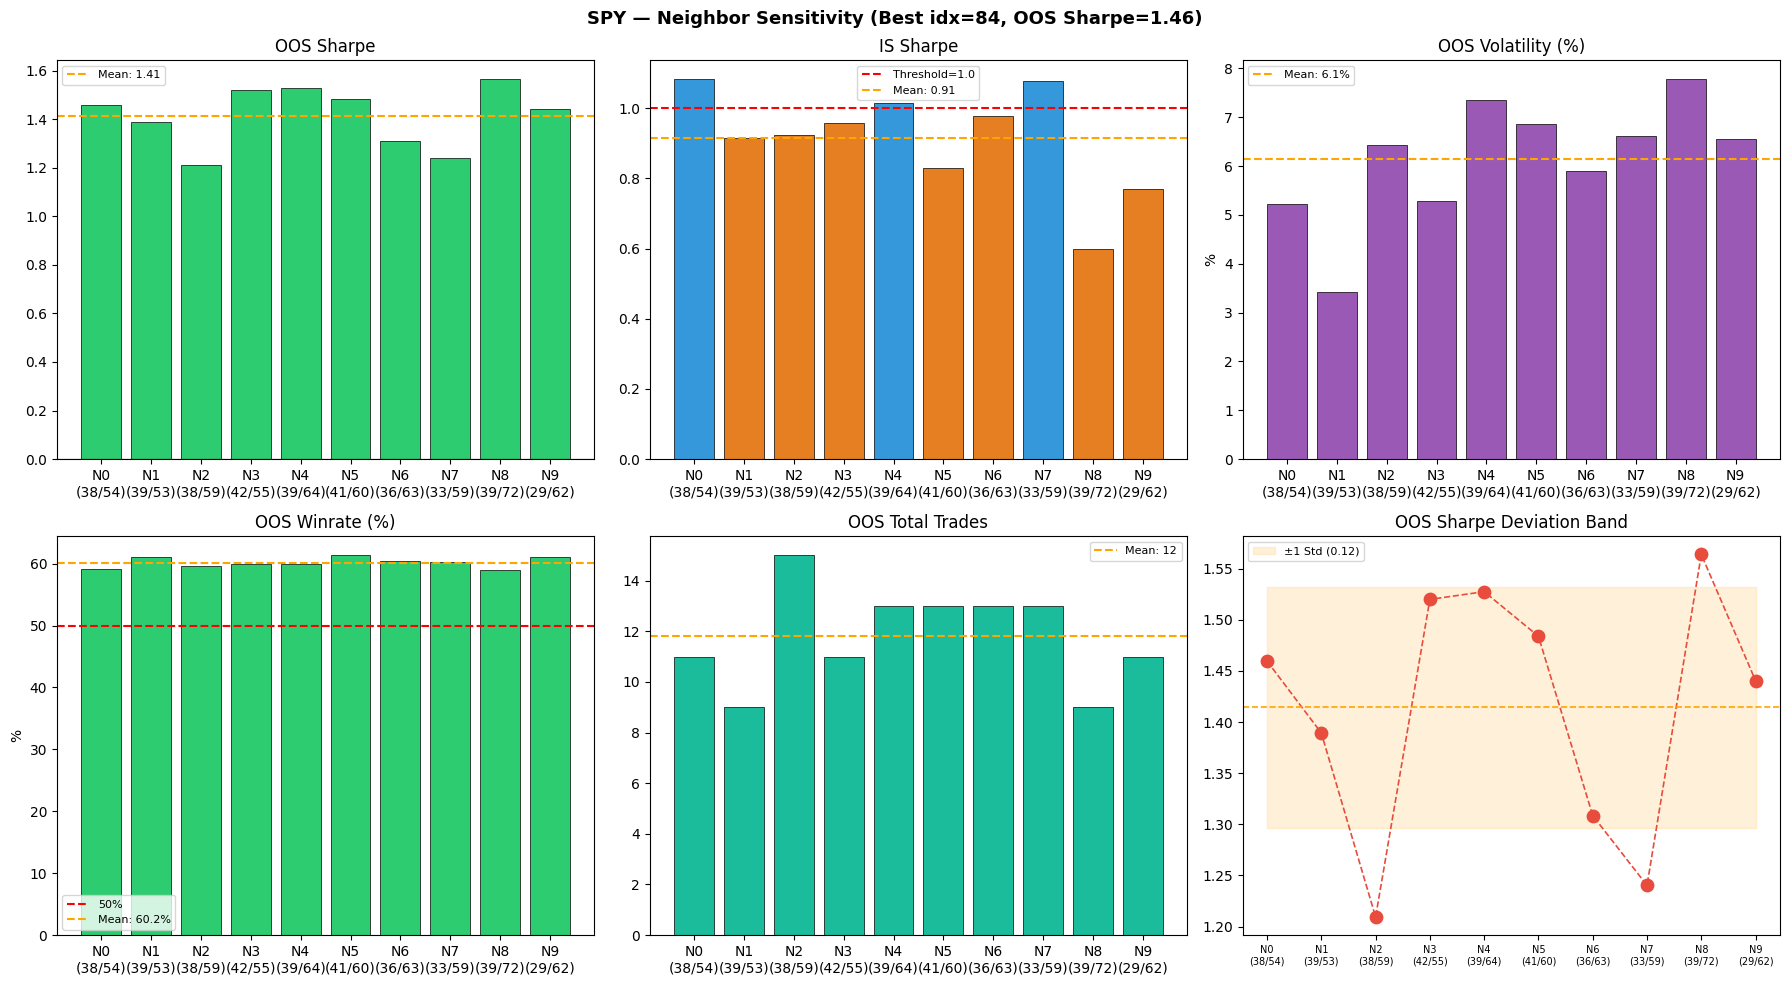


Top: SPY | OOS Sharpe: 1.4596 | OOS Std: 0.1175
Params: {'n_short': 38, 'fast_short': 3, 'slow_short': 31, 'n_long': 54, 'fast_long': 2, 'slow_long': 32}


In [7]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Find top OOS performer across all tickers
top_ticker, top_best, top_test_df, top_train_df = None, None, None, None

for ticker, (study, train_df, test_df) in studies.items():
    trials      = study.trials
    params_list = [t.params for t in trials]
    is_sharpes  = np.array([t.value for t in trials])

    p_keys   = list(params_list[0].keys())
    p_values = np.array([[p[k] for k in p_keys] for p in params_list])
    p_norm   = (p_values - p_values.min(0)) / (p_values.max(0) - p_values.min(0) + 1e-9)
    dist_mat = cdist(p_norm, p_norm)
    oos_sharpes = np.array([eval_params(p, test_df)[0] for p in params_list])

    qualified = [
        {'idx': i, 'is_sharpe': is_sharpes[i], 'oos_sharpe': oos_sharpes[i],
         'oos_std': np.std(oos_sharpes[np.argsort(dist_mat[i])[:10]]),
         'params': params_list[i]}
        for i in range(len(trials)) if is_sharpes[i] > 1.0
    ]
    if not qualified: continue

    best = min(qualified, key=lambda x: x['oos_std'])
    if top_best is None or best['oos_sharpe'] > top_best['oos_sharpe']:
        top_ticker       = ticker
        top_best         = best
        top_test_df      = test_df
        top_train_df     = train_df
        top_params_list  = params_list
        top_is_sharpes   = is_sharpes
        top_dist_mat     = dist_mat

# Get 10 nearest neighbors of best param set
best_idx  = top_best['idx']
neighbors = np.argsort(top_dist_mat[best_idx])[:10]

# Pull all metrics for each neighbor
neighbor_metrics = [eval_params(top_params_list[n], top_test_df) for n in neighbors]
neighbor_sharpe  = [m[0] for m in neighbor_metrics]
neighbor_vol     = [m[1] for m in neighbor_metrics]
neighbor_winrate = [m[2] for m in neighbor_metrics]
neighbor_trades  = [m[3] for m in neighbor_metrics]
neighbor_is      = [top_is_sharpes[n] for n in neighbors]

labels = [f"N{i}\n({top_params_list[neighbors[i]]['n_short']}/{top_params_list[neighbors[i]]['n_long']})"
          for i in range(len(neighbors))]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"{top_ticker} — Neighbor Sensitivity (Best idx={best_idx}, OOS Sharpe={top_best['oos_sharpe']:.2f})",
             fontsize=13, fontweight='bold')

# OOS Sharpe
c = ['#2ecc71' if v > 0 else '#e74c3c' for v in neighbor_sharpe]
axes[0,0].bar(labels, neighbor_sharpe, color=c, edgecolor='black', linewidth=0.5)
axes[0,0].axhline(np.mean(neighbor_sharpe), color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(neighbor_sharpe):.2f}')
axes[0,0].axhline(0, color='black', linewidth=0.8)
axes[0,0].set_title("OOS Sharpe")
axes[0,0].legend(fontsize=8)

# IS Sharpe
c = ['#3498db' if v > 1 else '#e67e22' for v in neighbor_is]
axes[0,1].bar(labels, neighbor_is, color=c, edgecolor='black', linewidth=0.5)
axes[0,1].axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Threshold=1.0')
axes[0,1].axhline(np.mean(neighbor_is), color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(neighbor_is):.2f}')
axes[0,1].set_title("IS Sharpe")
axes[0,1].legend(fontsize=8)

# Volatility
axes[0,2].bar(labels, [v * 100 for v in neighbor_vol], color='#9b59b6', edgecolor='black', linewidth=0.5)
axes[0,2].axhline(np.mean(neighbor_vol) * 100, color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(neighbor_vol)*100:.1f}%')
axes[0,2].set_title("OOS Volatility (%)")
axes[0,2].set_ylabel("%")
axes[0,2].legend(fontsize=8)

# Winrate
c = ['#2ecc71' if v > 0.5 else '#e74c3c' for v in neighbor_winrate]
axes[1,0].bar(labels, [v * 100 for v in neighbor_winrate], color=c, edgecolor='black', linewidth=0.5)
axes[1,0].axhline(50, color='red', linestyle='--', linewidth=1.5, label='50%')
axes[1,0].axhline(np.mean(neighbor_winrate) * 100, color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(neighbor_winrate)*100:.1f}%')
axes[1,0].set_title("OOS Winrate (%)")
axes[1,0].set_ylabel("%")
axes[1,0].legend(fontsize=8)

# Trades
axes[1,1].bar(labels, neighbor_trades, color='#1abc9c', edgecolor='black', linewidth=0.5)
axes[1,1].axhline(np.mean(neighbor_trades), color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(neighbor_trades):.0f}')
axes[1,1].set_title("OOS Total Trades")
axes[1,1].legend(fontsize=8)

# Sharpe deviation scatter
axes[1,2].scatter(range(len(neighbors)), neighbor_sharpe, color='#e74c3c', zorder=5, s=80)
axes[1,2].plot(range(len(neighbors)), neighbor_sharpe, color='#e74c3c', linewidth=1.2, linestyle='--')
axes[1,2].fill_between(range(len(neighbors)),
                        np.mean(neighbor_sharpe) - np.std(neighbor_sharpe),
                        np.mean(neighbor_sharpe) + np.std(neighbor_sharpe),
                        alpha=0.15, color='orange', label=f'±1 Std ({np.std(neighbor_sharpe):.2f})')
axes[1,2].axhline(np.mean(neighbor_sharpe), color='orange', linestyle='--', linewidth=1.2)
axes[1,2].set_title("OOS Sharpe Deviation Band")
axes[1,2].set_xticks(range(len(neighbors)))
axes[1,2].set_xticklabels(labels, fontsize=7)
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nTop: {top_ticker} | OOS Sharpe: {top_best['oos_sharpe']:.4f} | OOS Std: {np.std(neighbor_sharpe):.4f}")
print(f"Params: {top_best['params']}")